In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy

import xarray as xr
from scipy.stats import kendalltau
import seaborn as sns
from scipy.stats.mstats import theilslopes
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

import warnings
warnings.filterwarnings('ignore')


In [34]:
new = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
new.date = pd.to_datetime(new.date)
new.set_index('date', inplace=True)

old = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/full_records.csv')
old.date = pd.to_datetime(old.date)
old.set_index('date', inplace=True)



In [35]:
changed = ['71132','71120','75292','79713','21412','75288','71123','79704']
colors = ['red','green','yellow','blue','brown','black','cyan','magenta']

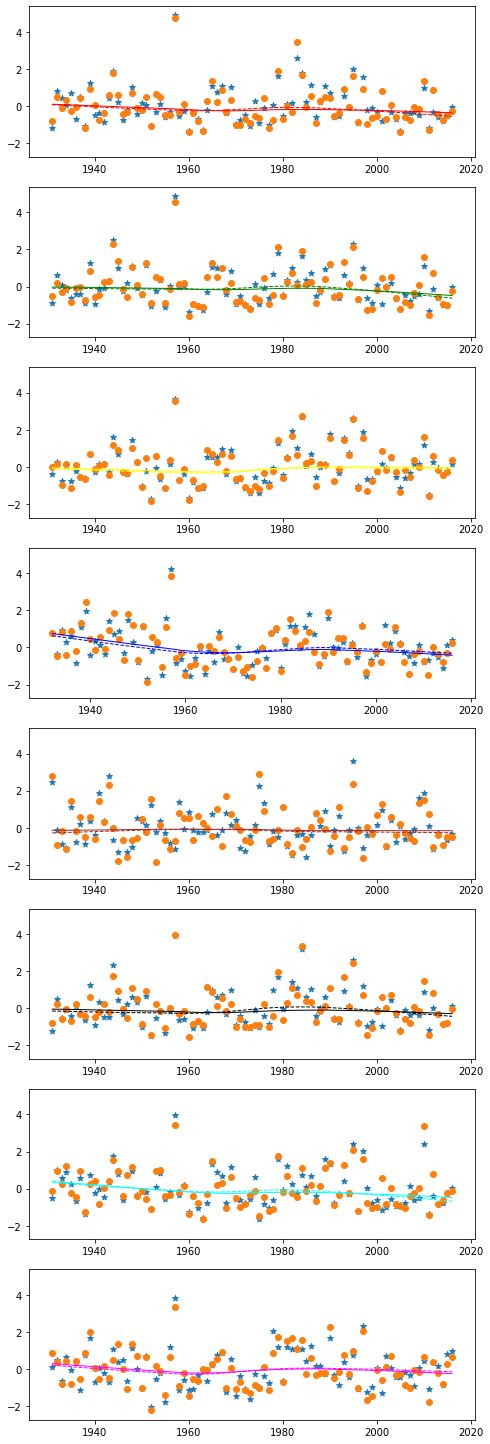

In [38]:
fig,axs = plt.subplots(8,1,sharey=True,figsize=(8,26))

for s in [12]:#,3,6,9]:
    for i,site in enumerate(changed):
        
        old_season = old[old.index.month.isin([s])]
        old_season = (old_season - old_season.mean()) / old_season.std()
        new_season = new[new.index.month.isin([s])]
        new_season = (new_season - new_season.mean()) / new_season.std()

        old_vals = np.array(old_season[site].values)
        old_years = np.array(old_season[site].index.year.values)

        lowess_fit = sm.nonparametric.lowess(old_vals, old_years, frac= 2./3, it=3, missing='drop')

        axs[i].scatter(old_years,old_vals,marker='*')
        axs[i].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, linestyle='--', c=colors[i],label=site) 

        
        new_vals = np.array(new_season[site].values)
        new_years = np.array(new_season[site].index.year.values)

        lowess_fit = sm.nonparametric.lowess(new_vals, new_years, frac= 2./3, it=3, missing='drop')
        
        axs[i].scatter(new_years,new_vals,marker='o')
        axs[i].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, c=colors[i],label=site) 


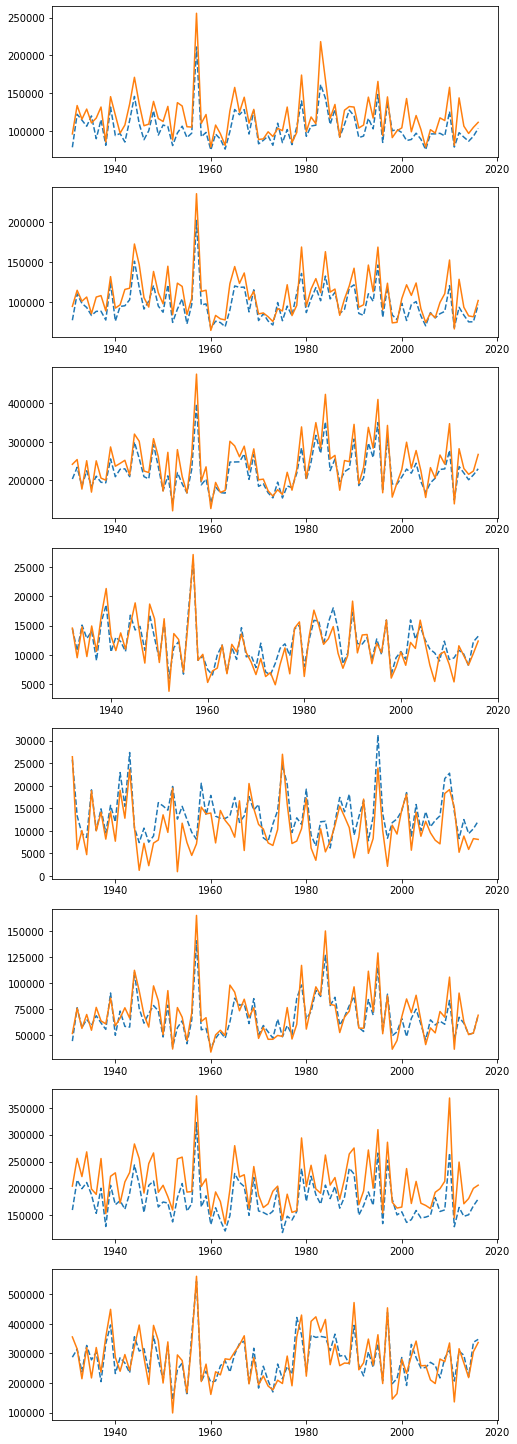

In [42]:
fig,axs = plt.subplots(8,1,figsize=(8,26))

for s in [12]:#,3,6,9]:
    for i,site in enumerate(changed):
        
        old_season = old[old.index.month.isin([s])]
        new_season = new[new.index.month.isin([s])]

        old_vals = np.array(old_season[site].values)*1000
        old_years = np.array(old_season[site].index.year.values)
        
        new_vals = np.array(new_season[site].values)
        new_years = np.array(new_season[site].index.year.values)
        
        axs[i].plot(old_years,old_vals,linestyle='--')
        axs[i].plot(new_years,new_vals,linestyle='-')


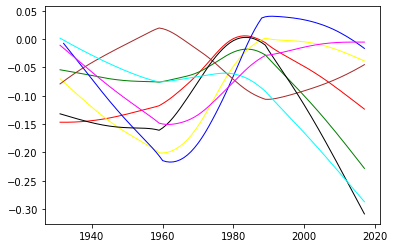

In [15]:
for i,site in enumerate(changed):
    new_vals = np.array(new[site].values)
    new_years = np.array(new[site].index.year.values)

    lowess_fit = sm.nonparametric.lowess(new_vals, new_years, frac= 2./3, it=3, missing='drop')

    plt.plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, c=colors[i],label=site) 


    
    

In [10]:
new['71132']

date
1931-12-01    0.388839
1932-03-01   -0.720393
1932-06-01   -1.880269
1932-09-01   -0.525295
1932-12-01    1.533601
                ...   
2018-12-01         NaN
2019-03-01         NaN
2019-06-01         NaN
2019-09-01         NaN
2019-12-01         NaN
Name: 71132, Length: 353, dtype: float64